In [3]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from network_idx.eda.correlations import (
    fetch_data_from_bq,
    compute_all_correlations,
    get_top_correlations,
    plot_correlation_heatmap,
    correlations_with_target
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Load features table from BQ - the geometry as a dataframe
tract_df = fetch_data_from_bq()

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [5]:
# Check the columns in the dataframe
tract_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85481 entries, 0 to 85480
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tract_geoid                            85481 non-null  str    
 1   pop_ch_1yr                             84178 non-null  float64
 2   pop_pctch_1yr                          84169 non-null  float64
 3   estimated_census_housing_units         85481 non-null  int64  
 4   estimated_fcc_units                    85481 non-null  int64  
 5   copper_speed_less_than_100_20          85481 non-null  float64
 6   copper_speed_100_20_only               85481 non-null  float64
 7   copper_speed_more_than_100_20          85481 non-null  float64
 8   cable_speed_less_than_100_20           85481 non-null  float64
 9   cable_speed_100_20_only                85481 non-null  float64
 10  cable_speed_more_than_100_20           85481 non-null  float64
 11  fiber_speed_l

In [7]:
# Rework tract_df to obtain meaningful relationships
tract_df_modified = tract_df.copy()
techs = ['copper','cable','fiber']
for tech in techs:
    tract_df_modified[f'{tech}_equal_more_than_100_20_units'] = tract_df_modified[f"{tech}_speed_100_20_only"].add(tract_df_modified[f"{tech}_speed_more_than_100_20"], fill_value=0)

# Compute % growth parcels
tract_df_modified['perc_growth_parcels'] = round(tract_df_modified['growth_parcels'] / tract_df_modified['total_parcels'],2)


# Remove redundant columns that are not relevant for the analysis
cols_to_drop = ['copper_speed_less_than_100_20',
                'copper_speed_100_20_only',
                'copper_speed_more_than_100_20',
                'cable_speed_less_than_100_20',
                'cable_speed_100_20_only',
                'cable_speed_more_than_100_20',
                'fiber_speed_less_than_100_20',
                'fiber_speed_100_20_only',
                'fiber_speed_more_than_100_20',
                'fiber_speed_equal_greater_than_100_20',
                #'cable_location_count',
                #'copper_location_count',
                #'fiber_location_count'
                'copper_max_upload_speed',
                'cable_max_upload_speed',
                'fiber_max_upload_speed',
                'total_parcels',
                'growth_parcels',
                'unique_locations',
                'total_flags',
                'flags_minus_greatest'
                ]

# Remove the columns that are not relevant for the analysis
tract_df_modified = tract_df_modified.drop(columns=cols_to_drop)

# Examine columns
tract_df_modified.info()

<class 'pandas.DataFrame'>
RangeIndex: 85481 entries, 0 to 85480
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   tract_geoid                          85481 non-null  str    
 1   pop_ch_1yr                           84178 non-null  float64
 2   pop_pctch_1yr                        84169 non-null  float64
 3   estimated_census_housing_units       85481 non-null  int64  
 4   estimated_fcc_units                  85481 non-null  int64  
 5   cable_location_count                 84909 non-null  float64
 6   cable_provider_count                 82151 non-null  float64
 7   cable_max_download_speed             82151 non-null  float64
 8   copper_location_count                84909 non-null  float64
 9   copper_provider_count                68752 non-null  float64
 10  copper_max_download_speed            68752 non-null  float64
 11  fiber_location_count                 84

Figure(1600x1400)


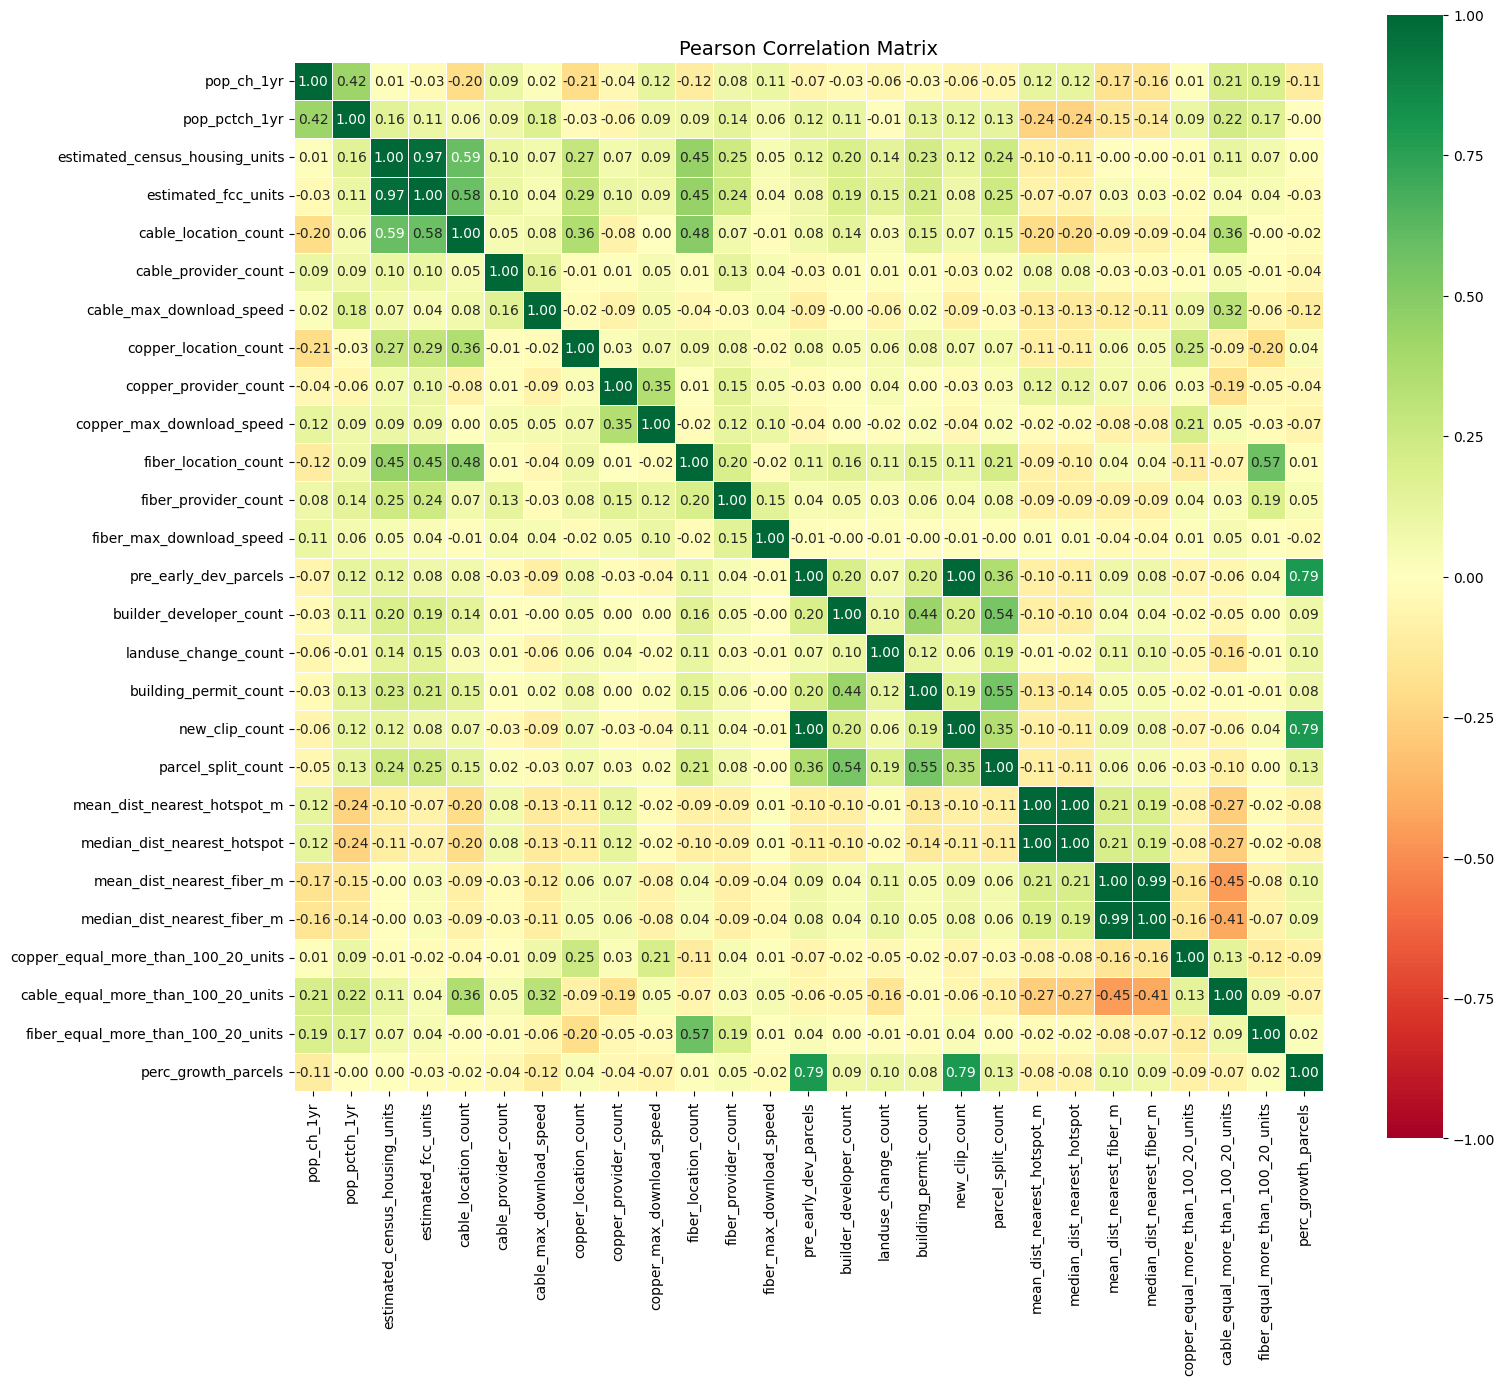

In [8]:
# Compute correlation matrix: pearson correlation that measures linear relationships between features
pearson_corr_matrix = plot_correlation_heatmap(tract_df_modified, method='pearson',cmap= "RdYlGn")
print(pearson_corr_matrix)

Figure(1600x1400)


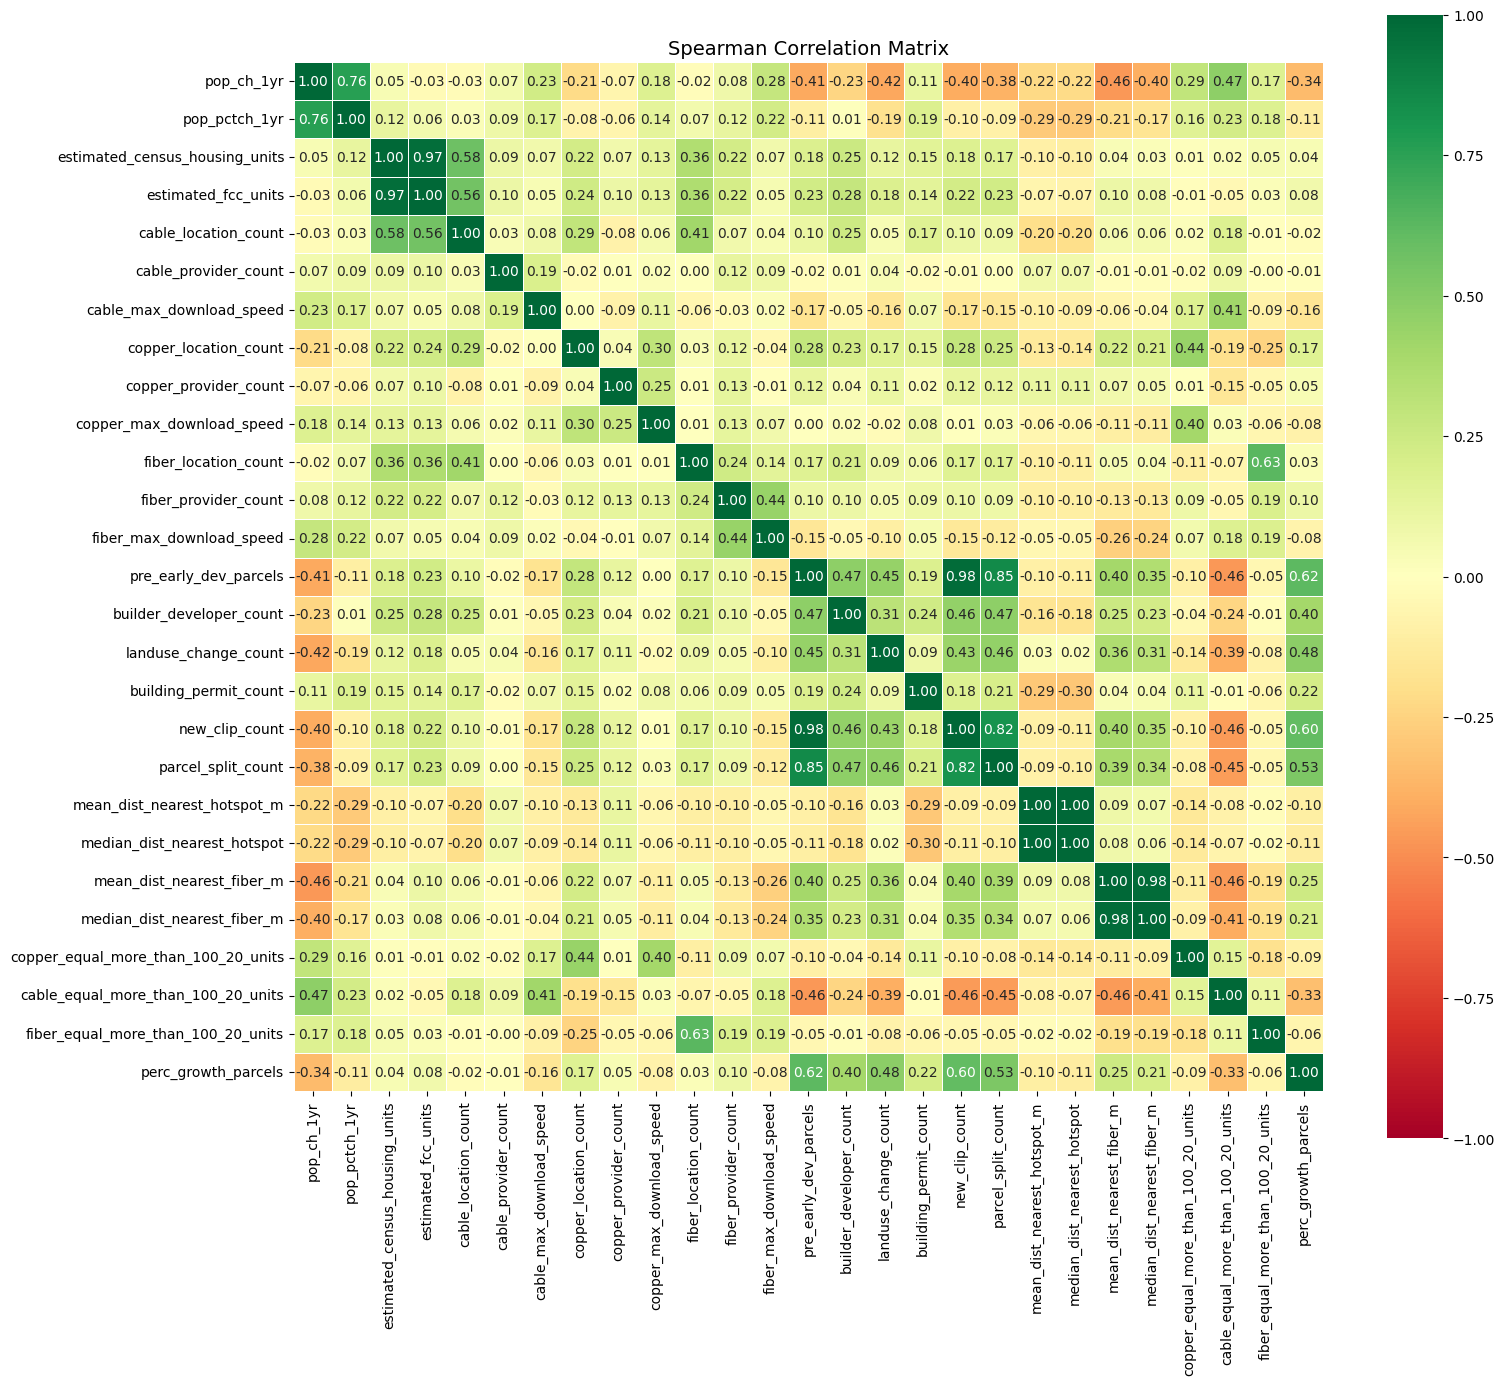

In [9]:
# Compute correlation matrix
spearman_corr_matrix = plot_correlation_heatmap(tract_df_modified, method='spearman',cmap= "RdYlGn")
print(spearman_corr_matrix)

In [10]:
# Compute top correlations: pearson
top_correlations = get_top_correlations(tract_df_modified, method="pearson", n=25,min_abs_corr=0.4)
print("Top correlations with target (pearson):")
print(top_correlations)

Top correlations with target (pearson):
                         feature_1                           feature_2  \
0            pre_early_dev_parcels                      new_clip_count   
1      mean_dist_nearest_hotspot_m         median_dist_nearest_hotspot   
2        mean_dist_nearest_fiber_m         median_dist_nearest_fiber_m   
3   estimated_census_housing_units                 estimated_fcc_units   
4            pre_early_dev_parcels                 perc_growth_parcels   
5                   new_clip_count                 perc_growth_parcels   
6   estimated_census_housing_units                cable_location_count   
7              estimated_fcc_units                cable_location_count   
8             fiber_location_count  fiber_equal_more_than_100_20_units   
9            building_permit_count                  parcel_split_count   
10         builder_developer_count                  parcel_split_count   
11            cable_location_count                fiber_location_count  

In [11]:
# Compute top correlations: pearson
top_correlations_sp = get_top_correlations(tract_df_modified, method="spearman", n=30,min_abs_corr=0.4)
print("Top correlations with target (spearman):")
print(top_correlations_sp)

Top correlations with target (spearman):
                         feature_1                            feature_2  \
0      mean_dist_nearest_hotspot_m          median_dist_nearest_hotspot   
1        mean_dist_nearest_fiber_m          median_dist_nearest_fiber_m   
2            pre_early_dev_parcels                       new_clip_count   
3   estimated_census_housing_units                  estimated_fcc_units   
4            pre_early_dev_parcels                   parcel_split_count   
5                   new_clip_count                   parcel_split_count   
6                       pop_ch_1yr                        pop_pctch_1yr   
7             fiber_location_count   fiber_equal_more_than_100_20_units   
8            pre_early_dev_parcels                  perc_growth_parcels   
9                   new_clip_count                  perc_growth_parcels   
10  estimated_census_housing_units                 cable_location_count   
11             estimated_fcc_units                 cable_lo